In [449]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pickle
from datetime import datetime

In [450]:
data = pd.read_excel("Data/dataset_comp_1222_without_ceg_ogn.xlsx")

## Calculate historical returns in the period 2018-2020:

In [451]:
# # Define the tickers and date range
# tickers = list(data['SYMBOL'].values) # Add more tickers as needed
# start_date = "2015-11-01"
# end_date = "2021-01-01"

# # Download the data
# yahoo_data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close_bt = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close_bt[tickers[0]] = yahoo_data['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close_bt[ticker] = yahoo_data[ticker]['Adj Close']
#         except KeyError:
#             print(f"No data found for {ticker}.")

# # Display the result
# print(adj_close_bt.head())

12 Failed downloads:
['SBNY', 'CEG', 'OGN']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-01 -> 2021-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1446350400, endDate = 1609477200")')
['MRO', 'CTLT', 'PXD', 'WRK', 'DISH', 'ATVI', 'SIVBQ']: YFTzMissingError('possibly delisted; no timezone found')
['DFS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-01 -> 2021-01-01) (Yahoo error = "No data found, symbol may be delisted")')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-01 -> 2021-01-01)')

In [452]:
# #print(data.loc[data['SYMBOL'] == 'BF.B'])
# # Define the tickers and date range
# tickers = ['BF-B'] # Add more tickers as needed
# start_date = "2015-11-01"
# end_date = "2021-01-01"

# # Download the data
# data_bfb = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close_bfb = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close_bfb[tickers[0]] = data_bfb['BF-B']['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close_bfb[ticker] = data_bfb[ticker]['Adj Close']
#         except KeyError:
#             print(f"No data found for {ticker}.")

# # Display the result
# #print(adj_close_bfb.head())
# adj_close_bt['BF.B'] = adj_close_bfb.values

In [453]:
# adj_close_bt.to_excel("Data/adj_price_yahoo_comp_1222_historical.xlsx")

In [454]:
adj_close_bt = pd.read_excel("Data/adj_price_yahoo_comp_1222_historical.xlsx")
adj_close_bt.index = adj_close_bt.Date
adj_close_bt.drop(columns='Date', inplace=True)


'CEG', 'OGN'

['DFS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-01 -> 2021-01-01) (Yahoo error = "No data found, symbol may be delisted")')

     

In [455]:
price_historical = pd.read_excel('Data/price_div_comp_1222_historical.xlsm', sheet_name='CLOSE PRICE', header = 4)

price_historical.columns = price_historical.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()

price_historical = price_historical.iloc[217:1566]

div_rate = pd.read_excel('Data/price_div_comp_1222_historical.xlsm', sheet_name='DIV RATE', header = 4)
div_rate.columns = div_rate.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
div_rate = div_rate.iloc[217:1566]

div_date_historical = pd.read_excel('Data/price_div_comp_1222_historical.xlsm', sheet_name='DIV DATE', header = 4)
div_date_historical.columns = div_date_historical.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
div_date_historical = div_date_historical.iloc[217:1566]

div_date_historical.columns = price_historical.columns
div_rate.columns = price_historical.columns

price_historical.index = price_historical.Code
div_rate.index = div_rate.Code
div_date_historical.index = div_date_historical.Code

price_historical = price_historical.iloc[:, 1:]
div_rate = div_rate.iloc[:, 1:]
div_date_historical = div_date_historical.iloc[:, 1:]

# --- Step 1: Calculate adjustment factors
adj_factors = pd.DataFrame(1.0, index=price_historical.index, columns=price_historical.columns)

for company in price_historical.columns:
    for i in range(1, len(price_historical)):
        date = price_historical.index[i]
        prev_date = price_historical.index[i - 1]

        # If ex-dividend happens on this day
        if pd.notna(div_date_historical.at[date, company]):
            div = div_rate.at[date, company]
            price_prev = price_historical.at[prev_date, company]
            if price_prev and price_prev != 0:
                factor = (price_prev - div) / price_prev
                adj_factors.at[date, company] = factor

# --- Step 2: Calculate cumulative adjustment factors in reverse (like Yahoo)
cum_factors = adj_factors.iloc[::-1].cumprod().iloc[::-1]

# --- Step 3: Build adjusted prices
adjusted_prices_calculated = price_historical * cum_factors

#print(data.loc[data['SYMBOL'] == 'WRK', 'NAME'])
#print(div_rate['96699P'].unique())
#print(price_historical['96699P'])
#print(adjusted_prices_calculated['96699P'])
adj_close_bt['WRK'] = adjusted_prices_calculated.loc[adj_close_bt.index, '96699P'].values

#print(data.loc[data['SYMBOL'] == 'CTLT', 'NAME'])
#print(div_rate['8866F3'].unique())
#print(price_historical['8866F3'])
#print(adjusted_prices_calculated['8866F3'])
adj_close_bt['CTLT'] = adjusted_prices_calculated.loc[adj_close_bt.index, ['8866F3']].values

#print(data.loc[data['SYMBOL'] == 'MRO', 'NAME'])
#print(div_rate['544682'].unique())
#print(price_historical['544682'])
#print(adjusted_prices_calculated['544682'])
adj_close_bt['MRO'] = adjusted_prices_calculated.loc[adj_close_bt.index, '544682'].values

#print(data.loc[data['SYMBOL'] == 'PXD', 'NAME'])
#print(div_rate['895705'].unique())
#print(price_historical['895705'])
adj_close_bt['PXD'] = adjusted_prices_calculated.loc[adj_close_bt.index, '895705'].values

#print(data.loc[data['SYMBOL'] == 'SBNY', ['NAME','TYPE']])
#print(div_rate['28709C'].unique())
#print(price_historical['28709C'])
adj_close_bt['SBNY'] = adjusted_prices_calculated.loc[adj_close_bt.index, '28709C'].values

#print(data.loc[data['SYMBOL'] == 'ATVI', ['NAME','TYPE']])
#print(div_rate['312367'].unique())
#print(price_historical['312367'])
adj_close_bt['ATVI'] = adjusted_prices_calculated.loc[adj_close_bt.index, '312367'].values

#print(data.loc[data['SYMBOL'] == 'DISH', ['NAME','TYPE']])
#print(div_rate['135448'].unique())
#print(price_historical['135448'])
adj_close_bt['DISH'] = adjusted_prices_calculated.loc[adj_close_bt.index, '135448'].values

#print(data.loc[data['SYMBOL'] == 'SIVBQ', ['NAME','TYPE']])
#print(div_rate['518628'].unique())
#print(price_historical['518628'])
adj_close_bt['SIVBQ'] = adjusted_prices_calculated.loc[adj_close_bt.index, '518628'].values

print(div_rate['50642F'].unique())
print(price_historical['50642F'])
adj_close_bt['DFS'] = adjusted_prices_calculated.loc[adj_close_bt.index, '50642F'].values

[ nan 0.28 0.3  0.35 0.4  0.44]
Code
2015-11-02    56.28
2015-11-03    56.35
2015-11-04    56.37
2015-11-05    56.91
2015-11-06    57.61
              ...  
2020-12-25    88.29
2020-12-28    88.29
2020-12-29    88.02
2020-12-30    89.30
2020-12-31    90.53
Name: 50642F, Length: 1349, dtype: float64


In [456]:
# ceg and ogn already excluded

In [457]:
#right now my log returns go from 15 dec 2020 to 15 dec 2021 (so the data goes back from 15 nov 2020)
# I could back test three years before so :

# 15 nov 2017 to 15 nov 2018
# 15 nov 2018 to 15 nov 2019
# 15 nov 2019 to 15 nov 2020

In [458]:

adj_close_bt_above_2018 = adj_close_bt.loc[adj_close_bt.index > datetime(2017, 11, 15)]
cols_with_nans = adj_close_bt_above_2018.columns[adj_close_bt_above_2018.isna().any()]
print("Columns with NaNs:", cols_with_nans.tolist())

nan_columns = adj_close_bt_above_2018.loc[:, adj_close_bt_above_2018.isna().any(axis=0)]

for col in nan_columns.columns:
    first_valid = nan_columns[col].first_valid_index()
    print(f"First non-NaN in column '{col}': {first_valid}") # these stocks had later IPO

Columns with NaNs: ['DAY', 'MRNA', 'DOW', 'FOXA', 'CARR', 'OTIS', 'CTVA', 'OGN', 'CEG', 'VICI']
First non-NaN in column 'DAY': 2018-04-26 00:00:00
First non-NaN in column 'MRNA': 2018-12-07 00:00:00
First non-NaN in column 'DOW': 2019-03-20 00:00:00
First non-NaN in column 'FOXA': 2019-03-12 00:00:00
First non-NaN in column 'CARR': 2020-03-19 00:00:00
First non-NaN in column 'OTIS': 2020-03-19 00:00:00
First non-NaN in column 'CTVA': 2019-05-24 00:00:00
First non-NaN in column 'OGN': None
First non-NaN in column 'CEG': None
First non-NaN in column 'VICI': 2018-01-02 00:00:00


VICI is okay, OGN and CEG I have to remove them in any case. For the rest I can take the optimized portfolio, and exclude these 7 stocks and then I can see how does it change in practice the optimised portfolio. After doing this I can evaluate the portfolio back in time. 

In [459]:
nan_backtest = ['DAY', 'MRNA', 'DOW', 'FOXA', 'CARR', 'OTIS', 'CTVA', 'VICI']
for stock in nan_backtest:
    stock_type_miss = data.loc[data['SYMBOL'] == stock, 'TYPE'].values
    if price_historical[stock_type_miss].first_valid_index() < nan_columns[stock].first_valid_index():
        print(stock, price_historical[stock_type_miss].first_valid_index())

VICI 2017-10-17 00:00:00


In [460]:
vici = price_historical['9174A0']
vici = vici[vici.index >= datetime(2017, 10, 1)]

In [461]:
adj_close_bt = adj_close_bt[(adj_close_bt.index >= datetime(2017, 10, 1))]

In [462]:
adj_close_bt['VICI'] = vici

In [463]:
adj_close_bt = adj_close_bt.drop(columns=['OGN', 'CEG', 'DAY', 'MRNA', 'DOW', 'FOXA', 'CARR', 'OTIS', 'CTVA'])

In [464]:
def calculate_monthly_returns(df):
    # Clean data: replace zeros and drop fully NaN rows
    df = df.replace(0.0, np.nan).dropna(how="all")
    
    # Resample to monthly frequency using last available price in each month
    df_monthly = df.resample("ME").last()
    
    # Calculate monthly simple returns (percentage change)
    df_returns = df_monthly.pct_change().dropna()
    
    # Optional: set index to mid-month for visualization consistency
    df_returns.index = df_returns.index.map(lambda x: x.replace(day=15))
    
    return df_returns

In [465]:
monthly_returns_2018_2020 = calculate_monthly_returns(adj_close_bt)

In [466]:
monthly_returns_2018_2020.to_excel("Data/monthly_returns_2018_2020.xlsx")

In [467]:
daily_returns_2018_2020 = adj_close_bt.pct_change().dropna()

In [468]:
daily_returns_2018_2020

,AMZN,ABT,AES,IBM,AMD,ADBE,ARE,APD,ALK,BXP,ALL,HON,AMGN,HES,AXP,AEP,AFL,AIG,ADI,VLO,CMCSA,ANSS,AAPL,AMAT,ALB,ADM,PNW,AEE,ADSK,ADP,AZO,AVY,BALL,BRK-B,BAX,BDX,AME,VZ,WRB,BBY,BIO,YUM,FE,BA,RHI,BWA,BSX,CHRW,TTWO,MTD,BMY,OKE,AVB,URI,SRE,FDX,VRSN,APH,BF.B,PWR,CSX,CTRA,CPB,CPT,STZ,CAH,CAT,JPM,CHD,CINF,CTAS,CSCO,CLX,KO,CPRT,CL,MAR,MOH,CMA,NRG,CAG,ED,CMS,COO,GLW,SEE,CMI,DHI,DHR,MCO,CTSH,TGT,DE,MS,RSG,CSGP,DIS,DLTR,DOV,OMC,DTE,DRI,EBAY,BAC,C,EMN,CDNS,DISH,ECL,RVTY,EA,CRM,EMR,ATO,ESS,ETR,EOG,EFX,EQR,EQT,EL,EXPD,XOM,FMC,NEE,FDS,AIZ,FAST,FITB,MTB,FI,BEN,FCX,AJG,GD,GIS,GPC,GILD,IT,MCK,NVDA,GWW,HAL,GS,HAS,HSIC,HSY,FFIV,JNPR,HOLX,HD,HRL,CNP,HUM,JBHT,HBAN,BIIB,IEX,ITW,INTU,IDXX,INTC,IFF,IP,IPG,JKHY,INCY,JNJ,HIG,KLAC,DVN,K,KEY,KIM,KMB,BLK,KR,LRCX,TDY,PKG,AKAM,LEN,LLY,LNC,UPS,A,LMT,L,CCL,LOW,D,MGM,MKC,MCD,EG,EW,HST,MMC,MAS,MLM,MET,ATVI,CVS,ON,LH,MSFT,MU,MAA,MCHP,MMM,MHK,CRL,ILMN,XEL,F,NTAP,NWL,NEM,NVR,NKE,NDSN,NSC,NI,NTRS,NOC,WFC,NUE,COF,OXY,ODFL,ORCL,PCAR,EXC,PH,PAYX,ALGN,PPL,PEP,PFE,COP,PCG,PXD,MO,PNC,BRO,PPG,COST,TROW,DGX,PG,PGR,PEG,PHM,GPN,QCOM,RJF,O,REG,UDR,REGN,RMD,USB,ACGL,ROST,ROL,ROP,ROK,RCL,TRV,FIS,MRK,SLB,SCHW,POOL,ZBH,COR,PFG,SHW,CNC,SIVBQ,SPG,AOS,SNA,PRU,AAP,EIX,SO,LUV,T,CVX,STT,SBUX,STLD,PSA,SYK,NFLX,SNPS,SYY,ISRG,TFX,TER,TXN,TXT,TMO,DVA,TSCO,TRMB,TYL,TSN,MRO,UNP,UNH,UHS,VTR,VFC,VRTX,VMC,VNO,WMT,WM,WAT,WST,SJM,WDC,WAB,WY,WHR,SWKS,WYNN,NDAQ,CME,WMB,LKQ,LNT,KMX,TJX,ZBRA,ZION,SBNY,RF,DPZ,MPWR,EXR,LVS,DLR,MKTX,CE,TAP,DXCM,CF,AMP,LYV,CMG,TDG,MA,FSLR,BR,DAL,DFS,BK,ULTA,IVZ,MSCI,PM,V,AWK,CB,MPC,MOS,KMI,XYL,SWK,LYB,GRMN,HII,PLD,EPAM,ACN,HCA,VRSK,UAL,CPAY,RL,FRCB,NXPI,TRGP,CBOE,DG,FTNT,MSI,TSLA,GNRC,TEL,ORLY,ENPH,GM,CBRE,EXPE,APTV,PSX,AMT,META,DUK,FANG,NOW,MDLZ,ETN,ABBV,TMUS,PTC,ZTS,NCLH,NWSA,CDW,AAL,KDP,INVH,WTW,BKR,LW,IQV,BKNG,LDOS,AVGO,TPR,EVRG,ALLE,ICE,STE,CI,AMCR,DOC,GEN,DD,GL,MTCH,LHX,TT,HWM,TFC,PARA,STX,GE,IR,PAYC,AON,PNR,RTX,WBD,LUMN,VTRS,CZR,ANET,FRT,J,APA,BBWI,CTLT,SYF,CFG,KEYS,QRVO,TECH,ELV,CCI,MDT,WBA,IRM,EQIX,ES,SEDG,ETSY,JCI,XRAY,WRK,KHC,FTV,SPGI,HLT,GOOGL,WELL,HPE,PYPL,VICI,HPQ,DXC,WEC,MNST,LIN,SBAC,CHTR
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-10-18,-0.012020,0.012895,-0.005362,0.088645,-0.006356,0.017422,-0.007494,-0.001759,-0.001118,-0.010854,-0.001750,0.000070,0.000484,-0.001958,0.004253,-0.002595,0.000000,-0.002986,0.000675,0.000000,-0.007403,-0.001002,-0.004424,0.003809,0.001793,-0.008244,-0.004786,0.000984,-0.001516,0.001847,-0.002566,-0.010533,0.003097,0.002455,-0.001252,0.022898,0.000000,0.005165,0.004675,0.014821,-0.003334,-0.002231,-0.005596,0.005491,0.022254,0.007112,0.004082,0.017364,0.006833,-0.009906,-0.007479,-0.018610,0.000334,0.006837,-0.008681,0.009995,0.006541,-0.000923,-0.005529,-0.001336,-0.010142,-0.010046,-0.010836,-0.005590,-0.008659,-0.005839,0.005745,0.003790,-0.006080,0.000922,0.000728,-0.001488,-0.006901,-0.002579,0.001099,-0.006937,0.006346,0.025187,0.023663,-0.001923,-0.003215,0.002633,0.000000,-0.000848,0.008426,-0.004292,0.001717,0.000482,0.009266,0.007424,-0.000406,-0.002327,0.000233,0.020969,0.000635,0.000106,-0.001118,-0.000655,-0.005104,-0.001852,0.003541,0.004904,0.012803,0.010687,0.012882,0.008705,-0.000478,0.017468,-0.006638,-0.003125,-0.024314,-0.002895,0.000458,0.002436,-0.000651,0.000709,-0.008107,0.018788,-0.002392,-0.006001,-0.004796,0.011548,-0.002411,-0.003813,-0.000852,0.003789,0.061965,0.010639,0.003575,-0.021445,0.003475,0.009236,-0.006698,0.004040,-0.005436,0.010638,0.012182,-0.002866,0.000737,-0.001366,-0.000860,0.016503,-0.015520,0.025160,0.001657,-0.001941,-0.006948,0.003956,-0.001149,0.002173,0.000612,-0.005395,0.001693,

## Realized TEs (with 2% TE Constraint) in the period 2018-2020:

In [469]:

with open('Data/optimal_portfolios_1222_without_ceg_ogn_minimum_weight.pkl', 'rb') as f:
    optimal_portfolios_shrink = pickle.load(f)


In [470]:
def compute_buy_and_hold_returns(returns_df, weights, stock_labels):
    """
    Compute buy-and-hold (non-rebalanced) portfolio returns.
    
    Args:
        returns_df: DataFrame with stock returns (monthly), index = date, columns = tickers
        weights: np.array of initial weights (must match stock_labels)
        stock_labels: list or Index of tickers in this sector

    Returns:
        Series of portfolio returns over time (monthly)
    """
    # Subset return data for the sector
    sector_returns = returns_df[stock_labels]
    
    # Compute cumulative returns per stock
    cumulative_returns = (1 + sector_returns).cumprod()
    
    # Multiply by initial weights
    weighted_growth = cumulative_returns.multiply(weights, axis=1)
    
    # Total portfolio value each month
    portfolio_value = weighted_growth.sum(axis=1)
    
    # Convert to monthly portfolio returns
    portfolio_returns = portfolio_value.pct_change().dropna()

    return portfolio_returns

def compute_fixed_weight_returns(returns_df, weights, stock_labels):
    """
    Compute fixed-weight portfolio returns (decarbonised portfolio).
    
    Args:
        returns_df: DataFrame of monthly returns
        weights: np.array of optimised weights
        stock_labels: list or Index of stock tickers

    Returns:
        Series of portfolio returns over time
    """
    sector_returns = returns_df[stock_labels]
    portfolio_returns = sector_returns.dot(weights)
    return portfolio_returns

In [471]:
monthly_returns_2018_2020

,AMZN,ABT,AES,IBM,AMD,ADBE,ARE,APD,ALK,BXP,ALL,HON,AMGN,HES,AXP,AEP,AFL,AIG,ADI,VLO,CMCSA,ANSS,AAPL,AMAT,ALB,ADM,PNW,AEE,ADSK,ADP,AZO,AVY,BALL,BRK-B,BAX,BDX,AME,VZ,WRB,BBY,BIO,YUM,FE,BA,RHI,BWA,BSX,CHRW,TTWO,MTD,BMY,OKE,AVB,URI,SRE,FDX,VRSN,APH,BF.B,PWR,CSX,CTRA,CPB,CPT,STZ,CAH,CAT,JPM,CHD,CINF,CTAS,CSCO,CLX,KO,CPRT,CL,MAR,MOH,CMA,NRG,CAG,ED,CMS,COO,GLW,SEE,CMI,DHI,DHR,MCO,CTSH,TGT,DE,MS,RSG,CSGP,DIS,DLTR,DOV,OMC,DTE,DRI,EBAY,BAC,C,EMN,CDNS,DISH,ECL,RVTY,EA,CRM,EMR,ATO,ESS,ETR,EOG,EFX,EQR,EQT,EL,EXPD,XOM,FMC,NEE,FDS,AIZ,FAST,FITB,MTB,FI,BEN,FCX,AJG,GD,GIS,GPC,GILD,IT,MCK,NVDA,GWW,HAL,GS,HAS,HSIC,HSY,FFIV,JNPR,HOLX,HD,HRL,CNP,HUM,JBHT,HBAN,BIIB,IEX,ITW,INTU,IDXX,INTC,IFF,IP,IPG,JKHY,INCY,JNJ,HIG,KLAC,DVN,K,KEY,KIM,KMB,BLK,KR,LRCX,TDY,PKG,AKAM,LEN,LLY,LNC,UPS,A,LMT,L,CCL,LOW,D,MGM,MKC,MCD,EG,EW,HST,MMC,MAS,MLM,MET,ATVI,CVS,ON,LH,MSFT,MU,MAA,MCHP,MMM,MHK,CRL,ILMN,XEL,F,NTAP,NWL,NEM,NVR,NKE,NDSN,NSC,NI,NTRS,NOC,WFC,NUE,COF,OXY,ODFL,ORCL,PCAR,EXC,PH,PAYX,ALGN,PPL,PEP,PFE,COP,PCG,PXD,MO,PNC,BRO,PPG,COST,TROW,DGX,PG,PGR,PEG,PHM,GPN,QCOM,RJF,O,REG,UDR,REGN,RMD,USB,ACGL,ROST,ROL,ROP,ROK,RCL,TRV,FIS,MRK,SLB,SCHW,POOL,ZBH,COR,PFG,SHW,CNC,SIVBQ,SPG,AOS,SNA,PRU,AAP,EIX,SO,LUV,T,CVX,STT,SBUX,STLD,PSA,SYK,NFLX,SNPS,SYY,ISRG,TFX,TER,TXN,TXT,TMO,DVA,TSCO,TRMB,TYL,TSN,MRO,UNP,UNH,UHS,VTR,VFC,VRTX,VMC,VNO,WMT,WM,WAT,WST,SJM,WDC,WAB,WY,WHR,SWKS,WYNN,NDAQ,CME,WMB,LKQ,LNT,KMX,TJX,ZBRA,ZION,SBNY,RF,DPZ,MPWR,EXR,LVS,DLR,MKTX,CE,TAP,DXCM,CF,AMP,LYV,CMG,TDG,MA,FSLR,BR,DAL,DFS,BK,ULTA,IVZ,MSCI,PM,V,AWK,CB,MPC,MOS,KMI,XYL,SWK,LYB,GRMN,HII,PLD,EPAM,ACN,HCA,VRSK,UAL,CPAY,RL,FRCB,NXPI,TRGP,CBOE,DG,FTNT,MSI,TSLA,GNRC,TEL,ORLY,ENPH,GM,CBRE,EXPE,APTV,PSX,AMT,META,DUK,FANG,NOW,MDLZ,ETN,ABBV,TMUS,PTC,ZTS,NCLH,NWSA,CDW,AAL,KDP,INVH,WTW,BKR,LW,IQV,BKNG,LDOS,AVGO,TPR,EVRG,ALLE,ICE,STE,CI,AMCR,DOC,GEN,DD,GL,MTCH,LHX,TT,HWM,TFC,PARA,STX,GE,IR,PAYC,AON,PNR,RTX,WBD,LUMN,VTRS,CZR,ANET,FRT,J,APA,BBWI,CTLT,SYF,CFG,KEYS,QRVO,TECH,ELV,CCI,MDT,WBA,IRM,EQIX,ES,SEDG,ETSY,JCI,XRAY,WRK,KHC,FTV,SPGI,HLT,GOOGL,WELL,HPE,PYPL,VICI,HPQ,DXC,WEC,MNST,LIN,SBAC,CHTR
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-11-15,0.064662,0.039462,-0.004704,0.009405,-0.009099,0.036024,0.025008,0.022643,0.052309,0.034659,0.097783,0.087388,0.009364,0.038949,0.022927,0.051910,0.050301,-0.071970,-0.051865,0.094553,0.041909,0.083973,0.020278,-0.063266,-0.046632,-0.016312,0.046745,0.031779,-0.122119,-0.015483,0.164987,0.074880,-0.067991,0.032470,0.018943,0.093641,0.077048,0.063088,0.017565,0.064845,0.234360,0.125390,0.047631,0.078719,0.106615,0.059429,-0.066098,0.103400,0.008134,-0.078256,0.024813,-0.030127,0.000000,0.127226,0.029702,0.025021,0.070499,0.041265,0.048755,0.004506,0.109750,0.046945,0.040743,0.000439,-0.004449,-0.043780,0.039396,0.038862,0.046874,0.072145,0.067924,0.092240,0.100846,0.003594,0.189308,0.028389,0.065733,0.153472,0.060328,0.106000,0.092798,0.042896,0.038828,0.003829,0.039577,0.090051,-0.047430,0.156439,0.022651,0.068844,-0.042895,0.025089,0.127785,0.032200,-0.001998,0.031175,0.071670,0.126137,0.028256,0.063254,0.046261,0.024918,-0.078905,0.032860,0.031628,0.017179,0.017377,0.043433,0.040257,0.018806,-0.110786,0.019347,0.013836,0.063676,-0.058835,0.012931,0.024532,0.055224,-0.006542,-0.046566,0.119844,0.116910,0.008528,0.016584,0.025607,0.055691,0.007921,0.115393,0.055709,0.017585,0.015607,0.028958,-0.004292,0.045615,0.020593,0.089368,0.053723,-0.002401,-0.035273,0.073977,-0.028822,0.126420,-0.022461,0.024489,0.004644,-0.090967,0.050998,0.106622,0.121791,0.102246,0.090185,0.169769,0.023697,0.021578,0.046915,0.043478,0.033723,0.057406,0

In [472]:
exclude_list = ['DAY', 'MRNA', 'DOW', 'FOXA', 'CARR', 'OTIS', 'CTVA']

# Copy to avoid modifying in place
adjusted_portfolios = {}

for sector, data in optimal_portfolios_shrink.items():
    stock_labels = data['stock_labels']
    w_b = data['w_b_vec']
    w_opt = data['w_opt']
    
    # Create a mask for stocks not in the exclude list
    keep_mask = ~stock_labels.isin(exclude_list)
    
    # Apply mask to weights and stock_labels
    w_b_new = w_b[keep_mask]
    w_opt_new = w_opt[keep_mask]
    labels_new = stock_labels[keep_mask]
    
    # Re-normalize weights to sum to 1
    w_b_new /= w_b_new.sum()
    w_opt_new /= w_opt_new.sum()
    
    # Store in new dictionary
    adjusted_portfolios[sector] = {
        'w_b_vec': w_b_new,
        'w_opt': w_opt_new,
        'stock_labels': labels_new
    }

    for sector, data in adjusted_portfolios.items():
        assert f"{data['w_b_vec'].sum():.4f}" == "1.0000"
        assert f"{data['w_opt'].sum():.4f}"  == "1.0000"

buy_and_hold_sector_returns = {}

for sector, data in adjusted_portfolios.items():
    w_b = data['w_b_vec']                 # initial benchmark weights
    tickers = data['stock_labels']       # stock labels for the sector
    
    # Compute sector-level buy-and-hold benchmark returns
    sector_returns = compute_buy_and_hold_returns(
        monthly_returns_2018_2020,
        weights=w_b,
        stock_labels=tickers
    )
    
    buy_and_hold_sector_returns[sector] = sector_returns
    print(len(sector_returns))
buy_and_hold_df = pd.DataFrame(buy_and_hold_sector_returns)

print(buy_and_hold_sector_returns['Energy'])

decarb_sector_returns = {}

for sector, data in adjusted_portfolios.items():
    w_opt = data['w_opt']
    tickers = data['stock_labels']
    
    sector_returns = compute_fixed_weight_returns(
        monthly_returns_2018_2020,
        weights=w_opt,
        stock_labels=tickers
    )
    
    decarb_sector_returns[sector] = sector_returns

print(decarb_sector_returns['Energy'])
sector_tracking_errors = {}

for sector in buy_and_hold_sector_returns:
    # Get returns
    r_b = buy_and_hold_sector_returns[sector]
    r_d = decarb_sector_returns[sector]
    
    # Align indices (just in case)
    common_index = r_b.index.intersection(r_d.index)
    active_returns = r_d.loc[common_index] - r_b.loc[common_index]
    
    # Monthly tracking error
    te_monthly = active_returns.std()
    
    # Annualised tracking error
    te_annualised = te_monthly * np.sqrt(12)
    
    # Store
    sector_tracking_errors[sector] = te_annualised


te_df_total = pd.DataFrame.from_dict(sector_tracking_errors, orient='index', columns=['Annualised Tracking Error'])
te_df_total = te_df_total.sort_values(by='Annualised Tracking Error', ascending=False)
print(te_df_total)

37
37
37
37
37
37
37
37
37
37
37
Date
2017-12-15    0.048743
2018-01-15    0.037275
2018-02-15   -0.106746
2018-03-15    0.019920
2018-04-15    0.091394
2018-05-15    0.033737
2018-06-15    0.010471
2018-07-15    0.015099
2018-08-15   -0.024334
2018-09-15    0.028526
2018-10-15   -0.107857
2018-11-15   -0.013931
2018-12-15   -0.116588
2019-01-15    0.105961
2019-02-15    0.033658
2019-03-15    0.022051
2019-04-15   -0.011481
2019-05-15   -0.104129
2019-06-15    0.091572
2019-07-15   -0.020960
2019-08-15   -0.076788
2019-09-15    0.039845
2019-10-15   -0.018728
2019-11-15    0.017758
2019-12-15    0.057184
2020-01-15   -0.108262
2020-02-15   -0.143432
2020-03-15   -0.338997
2020-04-15    0.305060
2020-05-15    0.021107
2020-06-15   -0.011843
2020-07-15   -0.056273
2020-08-15   -0.008142
2020-09-15   -0.141976
2020-10-15   -0.045933
2020-11-15    0.278676
2020-12-15    0.040003
dtype: float64
Date
2017-11-15    0.022600
2017-12-15    0.047408
2018-01-15    0.038142
2018-02-15   -0.112837

In [473]:
len(decarb_sector_returns)

11

Highest TE for Cons. Discretionary, Real Estate & Financials

In [474]:
def expected_shortfall(x: pd.Series, alpha: float = 0.05) -> float:
    """
    ES/CVaR of a return series at level alpha.
    Returns the (negative) mean of the worst alpha tail (i.e., average loss).
    If the series is too short, returns np.nan.
    """
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    var_alpha = np.percentile(x, 100 * alpha)
    tail = x[x <= var_alpha]
    if len(tail) == 0:
        return np.nan
    return tail.mean()  # likely negative for downside

sector_metrics = {}

for sector in buy_and_hold_sector_returns:
    r_b = buy_and_hold_sector_returns[sector]
    r_d = decarb_sector_returns[sector]

    # align
    idx = r_b.index.intersection(r_d.index)
    active = (r_d.loc[idx] - r_b.loc[idx]).dropna()

    if len(active) < 6:
        continue

    # Standard (variance-based) TE
    te_monthly = active.std()
    te_annual = te_monthly * np.sqrt(12)

    # Tail TE (ES / CVaR). Report absolute magnitude for readability.
    es_5 = expected_shortfall(active, alpha=0.05)         # negative number (downside)
    es_1 = expected_shortfall(active, alpha=0.01)         # deeper tail
    es_5_abs = abs(es_5)
    es_1_abs = abs(es_1)

    sector_metrics[sector] = {
        "TE_Annual": te_annual,          # variance-based, annualised
        "ES_5pct_monthly": es_5,         # negative value (avg worst 5% months)
        "ES_1pct_monthly": es_1,         # negative value (avg worst 1% months)
        "ES_5pct_abs": es_5_abs,         # positive magnitude
        "ES_1pct_abs": es_1_abs,
    }

te_df = pd.DataFrame.from_dict(sector_metrics, orient='index')
# Optional formatting in bps / %
print(te_df.sort_values("TE_Annual", ascending=False))

                        TE_Annual  ES_5pct_monthly  ES_1pct_monthly  \
Consumer Discretionary   0.067905        -0.058583        -0.069315   
Financials               0.040888        -0.028192        -0.034054   
Real Estate              0.039618        -0.030541        -0.040351   
Information Technology   0.038043        -0.025395        -0.029232   
Health Care              0.037749        -0.015639        -0.015995   
Industrials              0.037618        -0.028473        -0.031232   
Materials                0.035386        -0.020134        -0.025684   
Energy                   0.031850        -0.014191        -0.015212   
Utilities                0.031801        -0.015610        -0.017983   
Consumer Staples         0.025804        -0.012269        -0.013725   
Communication Services   0.018954        -0.009804        -0.012630   

                        ES_5pct_abs  ES_1pct_abs  
Consumer Discretionary     0.058583     0.069315  
Financials                 0.028192     0.034

Highest ES also for Cons. Discretionary, Real Estate & Financials

In [475]:

sector_metrics = {}  # New dictionary to store all metrics

rf_monthly = 0.0  # Assumed risk-free rate (adjust if needed)

for sector in buy_and_hold_sector_returns:
    # Get returns
    r_b = buy_and_hold_sector_returns[sector]
    r_d = decarb_sector_returns[sector]
    
    # Align indices
    common_index = r_b.index.intersection(r_d.index)
    r_b = r_b.loc[common_index]
    r_d = r_d.loc[common_index]
    active_returns = r_d - r_b

    # === Tracking Error ===
    te_monthly = active_returns.std()
    te_annualised = te_monthly * np.sqrt(12)

    # === Benchmark metrics ===
    ret_b = r_b.mean() * 12
    vol_b = r_b.std() * np.sqrt(12)
    sharpe_b = (ret_b - rf_monthly * 12) / vol_b if vol_b != 0 else np.nan

    # === Decarbonised metrics ===
    ret_d = r_d.mean() * 12
    vol_d = r_d.std() * np.sqrt(12)
    sharpe_d = (ret_d - rf_monthly * 12) / vol_d if vol_d != 0 else np.nan

    # Store all metrics
    sector_metrics[sector] = {
        "Annualised Tracking Error": round(te_annualised, 3),
        "Return_B": round(ret_b, 2),
        "Vol_B": round(vol_b, 2),
        "Sharpe_B": round(sharpe_b, 2),
        "Return_D": round(ret_d, 2),
        "Vol_D": round(vol_d, 2),
        "Sharpe_D": round(sharpe_d, 2)
    }

# Convert to DataFrame
metrics_df = pd.DataFrame.from_dict(sector_metrics, orient='index')
metrics_df = metrics_df.sort_values(by="Annualised Tracking Error", ascending=False)
print(metrics_df)


                        Annualised Tracking Error  Return_B  Vol_B  Sharpe_B  \
Consumer Discretionary                      0.068      0.40   0.29      1.37   
Financials                                  0.041      0.14   0.21      0.68   
Real Estate                                 0.040      0.12   0.16      0.78   
Health Care                                 0.038      0.18   0.16      1.08   
Information Technology                      0.038      0.40   0.23      1.72   
Industrials                                 0.038      0.15   0.22      0.69   
Materials                                   0.035      0.15   0.20      0.79   
Utilities                                   0.032      0.11   0.14      0.77   
Energy                                      0.032     -0.05   0.38     -0.13   
Consumer Staples                            0.026      0.15   0.14      1.07   
Communication Services                      0.019      0.19   0.19      0.98   

                        Return_D  Vol_D

Returns are similar between the benchmark portfolios and the decarbonised portfolios. Volatility is lower for Consumer Discretionary and Information Technology while is the same or only slightly higher for the other sectors. Sharpe Ratios do not differ much, the highest difference is 0.12 for Consumer Staples and Information Technology. Communication Services is the only one with higher Sharpe Ratio

## Testing TEs across 6 months time windows (period 2018-2020) using MONTHLY returns with 2% TE constraint:

In [476]:
sector_tracking_errors = {}
sector_tracking_errors_6m = {}

for sector in buy_and_hold_sector_returns:
    r_b = buy_and_hold_sector_returns[sector]
    r_d = decarb_sector_returns[sector]

    # Align indices
    common_index = r_b.index.intersection(r_d.index)
    r_b = r_b.loc[common_index]
    r_d = r_d.loc[common_index]

    df = pd.DataFrame({'r_b': r_b, 'r_d': r_d})
    df['active_return'] = df['r_d'] - df['r_b']

    six_month_windows = df.resample('6ME')
    te_annualised_list = []

    for _, window in six_month_windows:
        if len(window) >= 3:
            te_6m = window['active_return'].std()
            te_annualised = te_6m * np.sqrt(12)
            te_annualised_list.append(te_annualised)

            # Print the period for debugging
            start = window.index[0].date()
            end = window.index[-1].date()
            print(f"{sector}: {start} → {end}, TE = {te_annualised:.4%}")

    sector_tracking_errors_6m[sector] = te_annualised_list
    sector_tracking_errors[sector] = (
        np.mean(te_annualised_list) if te_annualised_list else np.nan
    )



Consumer Discretionary: 2018-01-15 → 2018-06-15, TE = 2.3227%
Consumer Discretionary: 2018-07-15 → 2018-12-15, TE = 3.7422%
Consumer Discretionary: 2019-01-15 → 2019-06-15, TE = 3.0718%
Consumer Discretionary: 2019-07-15 → 2019-12-15, TE = 5.7136%
Consumer Discretionary: 2020-01-15 → 2020-06-15, TE = 4.8521%
Consumer Discretionary: 2020-07-15 → 2020-12-15, TE = 12.1584%
Health Care: 2018-01-15 → 2018-06-15, TE = 2.7682%
Health Care: 2018-07-15 → 2018-12-15, TE = 1.8584%
Health Care: 2019-01-15 → 2019-06-15, TE = 5.7166%
Health Care: 2019-07-15 → 2019-12-15, TE = 4.5108%
Health Care: 2020-01-15 → 2020-06-15, TE = 3.1102%
Health Care: 2020-07-15 → 2020-12-15, TE = 5.0521%
Utilities: 2018-01-15 → 2018-06-15, TE = 1.4561%
Utilities: 2018-07-15 → 2018-12-15, TE = 1.9044%
Utilities: 2019-01-15 → 2019-06-15, TE = 3.0246%
Utilities: 2019-07-15 → 2019-12-15, TE = 3.1951%
Utilities: 2020-01-15 → 2020-06-15, TE = 5.7928%
Utilities: 2020-07-15 → 2020-12-15, TE = 3.2207%
Information Technology: 201

CAR
Cumulative active return = the compounded value of all these period-by-period active returns, across the whole backtest horizon.

Geometric mean of CAR =  "If every 6-month period had the same return, what constant return would reproduce the same overall compounded effect?"


Example with the Energy sector that has GeoMean_CAR_Annual = 0.0156 = +1.56% per year.

Interpretation: If the active return had been the same every 6 months, compounded consistently, it would correspond to an annualised active return of +1.56%.

In practice: the optimized Energy portfolio outperformed the Energy benchmark by about 1.56% per year on average, after accounting for ups and downs across different 6-month windows.

In [477]:
with open('Data/buy_and_hold_sector_returns.pkl', 'wb') as f:
    pickle.dump(buy_and_hold_sector_returns, f)

The TE is much lower if it is averaged across 6-months time windows. The difference is extremely large for Consumer Discretionary (8.0% vs 2.7%), for Real Estate (4.2% vs 1.4%) and for Financials (4.1% vs 1.7%). In general TE calculated in the entire period 2018-2020 have a mean of 3.7% across sectors while only 1.4% when calculated by averaging the TE across all the 6 months time windows. 

In [478]:
# Containers
sector_tracking_errors_6m = {}
sharpe_ratios_b_6m = {}
sharpe_ratios_d_6m = {}
returns_b_6m = {}
returns_d_6m = {}
vol_b_6m = {}
vol_d_6m = {}

summary_metrics = {}

for sector in buy_and_hold_sector_returns:
    r_b = buy_and_hold_sector_returns[sector]
    r_d = decarb_sector_returns[sector]

    # Align indices
    common_index = r_b.index.intersection(r_d.index)
    r_b = r_b.loc[common_index]
    r_d = r_d.loc[common_index]

    df = pd.DataFrame({'r_b': r_b, 'r_d': r_d})
    df['active_return'] = df['r_d'] - df['r_b']

    six_month_windows = df.resample('6ME')

    te_annualised_list = []
    sharpe_b_list = []
    sharpe_d_list = []
    return_b_list = []
    return_d_list = []
    vol_b_list = []
    vol_d_list = []

    for _, window in six_month_windows:
        if len(window) >= 3:
            # --- Tracking Error ---
            te_6m = window['active_return'].std()
            te_annualised = te_6m * np.sqrt(12)
            te_annualised_list.append(te_annualised)

            # --- Benchmark Metrics ---
            r_b_win = window['r_b']
            mean_b = r_b_win.mean() * 12
            std_b = r_b_win.std() * np.sqrt(12)
            sharpe_b = mean_b / std_b if std_b != 0 else np.nan
            return_b_list.append(mean_b)
            vol_b_list.append(std_b)
            sharpe_b_list.append(sharpe_b)

            # --- Decarb Metrics ---
            r_d_win = window['r_d']
            mean_d = r_d_win.mean() * 12
            std_d = r_d_win.std() * np.sqrt(12)
            sharpe_d = mean_d / std_d if std_d != 0 else np.nan
            return_d_list.append(mean_d)
            vol_d_list.append(std_d)
            sharpe_d_list.append(sharpe_d)

    # Store lists per sector
    sector_tracking_errors_6m[sector] = te_annualised_list
    returns_b_6m[sector] = return_b_list
    returns_d_6m[sector] = return_d_list
    vol_b_6m[sector] = vol_b_list
    vol_d_6m[sector] = vol_d_list
    sharpe_ratios_b_6m[sector] = sharpe_b_list
    sharpe_ratios_d_6m[sector] = sharpe_d_list

    # Store averaged metrics in summary table
    summary_metrics[sector] = {
        "Avg_TE": np.nanmean(te_annualised_list),
        "Avg_Return_B": np.nanmean(return_b_list),
        "Avg_Return_D": np.nanmean(return_d_list),
        "Avg_Vol_B": np.nanmean(vol_b_list),
        "Avg_Vol_D": np.nanmean(vol_d_list),
        "Avg_Sharpe_B": np.nanmean(sharpe_b_list),
        "Avg_Sharpe_D": np.nanmean(sharpe_d_list)
    }

# Get max number of 6M periods
max_periods = max(len(v) for v in sector_tracking_errors_6m.values())

# Build detailed rows
detailed_rows = {}

for sector in sector_tracking_errors_6m:
    row = {}

    # TE per 6M
    te_list = sector_tracking_errors_6m[sector]
    for i, val in enumerate(te_list):
        row[f"TE_{i+1}"] = val
    row["Avg_TE"] = np.nanmean(te_list)

    # Returns Benchmark
    ret_b_list = returns_b_6m[sector]
    for i, val in enumerate(ret_b_list):
        row[f"Return_B_{i+1}"] = val
    row["Avg_Return_B"] = np.nanmean(ret_b_list)

    # Returns Decarb
    ret_d_list = returns_d_6m[sector]
    for i, val in enumerate(ret_d_list):
        row[f"Return_D_{i+1}"] = val
    row["Avg_Return_D"] = np.nanmean(ret_d_list)

    # Volatility Benchmark
    vol_b_list = vol_b_6m[sector]
    for i, val in enumerate(vol_b_list):
        row[f"Vol_B_{i+1}"] = val
    row["Avg_Vol_B"] = np.nanmean(vol_b_list)

    # Volatility Decarb
    vol_d_list = vol_d_6m[sector]
    for i, val in enumerate(vol_d_list):
        row[f"Vol_D_{i+1}"] = val
    row["Avg_Vol_D"] = np.nanmean(vol_d_list)

    # Sharpe Benchmark
    sharpe_b_list = sharpe_ratios_b_6m[sector]
    for i, val in enumerate(sharpe_b_list):
        row[f"Sharpe_B_{i+1}"] = val
    row["Avg_Sharpe_B"] = np.nanmean(sharpe_b_list)

    # Sharpe Decarb
    sharpe_d_list = sharpe_ratios_d_6m[sector]
    for i, val in enumerate(sharpe_d_list):
        row[f"Sharpe_D_{i+1}"] = val
    row["Avg_Sharpe_D"] = np.nanmean(sharpe_d_list)

    detailed_rows[sector] = row
# Create full table
detailed_df = pd.DataFrame.from_dict(detailed_rows, orient='index')

# Round columns selectively
rounded_df = detailed_df.copy()
for col in rounded_df.columns:
    if col.startswith("TE_") or col == "Avg_TE":
        rounded_df[col] = rounded_df[col].round(3)
    else:
        rounded_df[col] = rounded_df[col].round(2)

# Optional: sort by average Sharpe_D
rounded_df = rounded_df.sort_values(by="Avg_Sharpe_D", ascending=False)

# Display the full table
pd.set_option('display.max_columns', None)
print(rounded_df)


                         TE_1   TE_2   TE_3   TE_4   TE_5   TE_6  Avg_TE  \
Information Technology  0.025  0.027  0.030  0.052  0.042  0.029   0.034   
Consumer Staples        0.013  0.023  0.043  0.023  0.017  0.028   0.025   
Consumer Discretionary  0.023  0.037  0.031  0.057  0.049  0.122   0.053   
Utilities               0.015  0.019  0.030  0.032  0.058  0.032   0.031   
Communication Services  0.028  0.021  0.021  0.008  0.007  0.014   0.017   
Real Estate             0.015  0.026  0.018  0.012  0.062  0.071   0.034   
Health Care             0.028  0.019  0.057  0.045  0.031  0.051   0.038   
Industrials             0.021  0.030  0.026  0.015  0.041  0.073   0.034   
Financials              0.029  0.023  0.028  0.052  0.059  0.051   0.040   
Materials               0.014  0.027  0.025  0.032  0.043  0.059   0.033   
Energy                  0.015  0.014  0.032  0.033  0.051  0.035   0.030   

                        Return_B_1  Return_B_2  Return_B_3  Return_B_4  \
Information T

In any case the Sharpe Ratios are a bit higher for the benchmark portfolios except for the Communication Services sector. 

In [479]:
summary_df = pd.DataFrame.from_dict(summary_metrics, orient='index')

# Optional: round and sort
summary_df = summary_df.round({
    "Avg_TE": 3,
    "Avg_Return_B": 2,
    "Avg_Return_D": 2,
    "Avg_Vol_B": 2,
    "Avg_Vol_D": 2,
    "Avg_Sharpe_B": 2,
    "Avg_Sharpe_D": 2
})

summary_df = summary_df.sort_values(by="Avg_Sharpe_D", ascending=False)

# Display full columns
pd.set_option('display.max_columns', None)
print(summary_df)


                        Avg_TE  Avg_Return_B  Avg_Return_D  Avg_Vol_B  \
Information Technology   0.034          0.42          0.36       0.23   
Consumer Staples         0.025          0.14          0.14       0.13   
Consumer Discretionary   0.053          0.40          0.35       0.26   
Utilities                0.031          0.13          0.12       0.13   
Communication Services   0.017          0.18          0.20       0.19   
Real Estate              0.034          0.13          0.13       0.15   
Health Care              0.038          0.18          0.18       0.17   
Industrials              0.034          0.15          0.14       0.21   
Financials               0.040          0.14          0.14       0.20   
Materials                0.033          0.15          0.15       0.18   
Energy                   0.030         -0.07         -0.06       0.35   

                        Avg_Vol_D  Avg_Sharpe_B  Avg_Sharpe_D  
Information Technology       0.22          2.08          2.

- 5 cases in which returns are higher for the decarb. portfolios (and 2 are same)
- 3 cases in which volatility is lower for the decarb. portfolios  (and 2 are same)
- 4 cases in which sharpe ratio is higher for the decarb. portfolios 


## Realized TEs with DAILY returns over 6 months rolling periods 

In [480]:
buy_and_hold_sector_daily_returns = {}

for sector, data in adjusted_portfolios.items():
    w_b = data['w_b_vec']                 # initial benchmark weights
    tickers = data['stock_labels']       # stock labels for the sector
    
    # Compute sector-level buy-and-hold benchmark returns
    sector_returns = compute_buy_and_hold_returns(
        daily_returns_2018_2020,
        weights=w_b,
        stock_labels=tickers
    )
    
    buy_and_hold_sector_daily_returns[sector] = sector_returns
    print(len(sector_returns))

decarb_sector_daily_returns = {}

for sector, data in adjusted_portfolios.items():
    w_opt = data['w_opt']
    tickers = data['stock_labels']
    
    sector_returns = compute_fixed_weight_returns(
        daily_returns_2018_2020,
        weights=w_opt,
        stock_labels=tickers
    )
    
    decarb_sector_daily_returns[sector] = sector_returns

806
806
806
806
806
806
806
806
806
806
806


In [481]:
window_size = 126  # ~6 months of trading days

for sector in buy_and_hold_sector_daily_returns:
    r_b = buy_and_hold_sector_daily_returns[sector]
    r_d = decarb_sector_daily_returns[sector]

    # Align
    common_index = r_b.index.intersection(r_d.index)
    active_returns = (r_d.loc[common_index] - r_b.loc[common_index]).dropna()

    # Loop manually through rolling windows
    for start in range(0, len(active_returns) - window_size + 1):
        end = start + window_size
        window = active_returns.iloc[start:end]
        start_date = window.index[0]
        end_date = window.index[-1]

        te_daily = window.std()
        te_ann = te_daily * np.sqrt(252)

        print(f"{sector}: {start_date.date()} → {end_date.date()}, TE={te_ann:.4%}")


Consumer Discretionary: 2017-10-19 → 2018-04-20, TE=2.7153%
Consumer Discretionary: 2017-10-20 → 2018-04-23, TE=2.7055%
Consumer Discretionary: 2017-10-23 → 2018-04-24, TE=2.7469%
Consumer Discretionary: 2017-10-24 → 2018-04-25, TE=2.7539%
Consumer Discretionary: 2017-10-25 → 2018-04-26, TE=2.8060%
Consumer Discretionary: 2017-10-26 → 2018-04-27, TE=2.8135%
Consumer Discretionary: 2017-10-27 → 2018-04-30, TE=2.8447%
Consumer Discretionary: 2017-10-30 → 2018-05-01, TE=2.8419%
Consumer Discretionary: 2017-10-31 → 2018-05-02, TE=2.8588%
Consumer Discretionary: 2017-11-01 → 2018-05-03, TE=2.8681%
Consumer Discretionary: 2017-11-02 → 2018-05-04, TE=2.8590%
Consumer Discretionary: 2017-11-03 → 2018-05-07, TE=2.8577%
Consumer Discretionary: 2017-11-06 → 2018-05-08, TE=2.8591%
Consumer Discretionary: 2017-11-07 → 2018-05-09, TE=2.8575%
Consumer Discretionary: 2017-11-08 → 2018-05-10, TE=2.8404%
Consumer Discretionary: 2017-11-09 → 2018-05-11, TE=2.8373%
Consumer Discretionary: 2017-11-10 → 201

ROLLING 6 months:

In [482]:
import numpy as np
import pandas as pd

# --- Backward robustness test ---
sector_tracking_errors = {}
sector_tracking_errors_rolling = {}

for sector in buy_and_hold_sector_daily_returns:  # these are fixed-weight benchmarks
    r_b = buy_and_hold_sector_daily_returns[sector]   # benchmark (buy & hold)
    r_d = decarb_sector_daily_returns[sector]         # optimized decarbonised

    # --- Align indices ---
    common_index = r_b.index.intersection(r_d.index)
    r_b = r_b.loc[common_index]
    r_d = r_d.loc[common_index]

    # --- Daily active returns ---
    active_returns = r_d - r_b

    # --- Rolling 6M TE (126 trading days) ---
    rolling_te = active_returns.rolling(window=126).std() * np.sqrt(252)

    # Store series + average
    sector_tracking_errors_rolling[sector] = rolling_te
    sector_tracking_errors[sector] = rolling_te.mean()  # average TE across whole sample

# --- Build Summary Table ---
te_df = pd.DataFrame(sector_tracking_errors, index=["Avg_TE"]).T
print(te_df.round(4).sort_values(by="Avg_TE", ascending=False))

# Optional: collect all rolling TE into a DataFrame for plotting
rolling_df = pd.DataFrame(sector_tracking_errors_rolling)

                        Avg_TE
Consumer Discretionary  0.0546
Real Estate             0.0449
Financials              0.0449
Materials               0.0426
Information Technology  0.0415
Utilities               0.0391
Health Care             0.0374
Industrials             0.0350
Consumer Staples        0.0310
Energy                  0.0306
Communication Services  0.0233


fixed 6 months + recomputing the buy and hold returns at the beginning of each time period:

In [483]:
import numpy as np
import pandas as pd

def compute_buy_and_hold_returns_window(returns_df, weights, stock_labels, start, end):
    """
    Compute buy-and-hold portfolio returns for a specific window.
    """
    sector_returns = returns_df.loc[start:end, stock_labels]
    
    # cumulative growth
    cumulative_returns = (1 + sector_returns).cumprod()
    
    # apply weights
    weighted_growth = cumulative_returns.multiply(weights, axis=1)
    
    # portfolio value & returns
    portfolio_value = weighted_growth.sum(axis=1)
    portfolio_returns = portfolio_value.pct_change().dropna()
    return portfolio_returns


# --- Backward robustness test ---
sector_tracking_errors = {}
sector_tracking_errors_6m = {}

window_size = 126  # ~6 months daily
for sector, data in adjusted_portfolios.items():
    tickers = data['stock_labels']
    w_b = data['w_b_vec']        # benchmark weights at Dec 2022
    w_opt = data['w_opt']        # optimised weights at Dec 2022

    # align returns for this sector
    r_sector = adj_close_bt[tickers].dropna().pct_change().dropna()


    te_list = []
    # loop over 6M non-overlapping windows
    for start_idx in range(0, len(r_sector), window_size):
        window = r_sector.iloc[start_idx:start_idx+window_size]
        if len(window) < 60:  # require at least ~3 months
            continue
        
        # recompute buy-and-hold portfolio starting at this window
        r_b = compute_buy_and_hold_returns_window(window, w_b, tickers, window.index[0], window.index[-1])
      
        # fixed-weight decarb portfolio for same window
        r_d = window.dot(w_opt)
        
        # align & compute active returns
        common_idx = r_b.index.intersection(r_d.index)
        active = r_d.loc[common_idx] - r_b.loc[common_idx]
        
        # TE for this window
        te_daily = active.std()
        te_ann = te_daily * np.sqrt(252)
        te_list.append(te_ann)

        print(f"{sector}: {window.index[0].date()} → {window.index[-1].date()}, TE={te_ann:.4%}")

    # save per-sector results
    sector_tracking_errors_6m[sector] = te_list
    sector_tracking_errors[sector] = np.mean(te_list) if te_list else np.nan


# --- Summary table ---
max_periods = max(len(v) for v in sector_tracking_errors_6m.values())
rows = {}
for sector, te_list in sector_tracking_errors_6m.items():
    row = te_list + [np.nan] * (max_periods - len(te_list))
    row.append(np.mean(te_list) if te_list else np.nan)
    rows[sector] = row

columns = [f"TE_window_{i+1}" for i in range(max_periods)] + ["Avg_TE"]
te_df = pd.DataFrame.from_dict(rows, orient="index", columns=columns)

print(te_df.round(4).sort_values(by="Avg_TE", ascending=False))


Consumer Discretionary: 2017-10-03 → 2018-04-04, TE=2.7714%
Consumer Discretionary: 2018-04-05 → 2018-10-02, TE=2.5687%
Consumer Discretionary: 2018-10-03 → 2019-04-04, TE=3.0577%
Consumer Discretionary: 2019-04-05 → 2019-10-03, TE=2.5385%
Consumer Discretionary: 2019-10-04 → 2020-04-03, TE=10.7214%
Consumer Discretionary: 2020-04-06 → 2020-10-02, TE=8.1676%
Consumer Discretionary: 2020-10-05 → 2020-12-31, TE=3.3948%
Health Care: 2017-10-03 → 2018-04-04, TE=2.8789%
Health Care: 2018-04-05 → 2018-10-02, TE=2.7479%
Health Care: 2018-10-03 → 2019-04-04, TE=3.6147%
Health Care: 2019-04-05 → 2019-10-03, TE=3.4309%
Health Care: 2019-10-04 → 2020-04-03, TE=5.2852%
Health Care: 2020-04-06 → 2020-10-02, TE=3.1832%
Health Care: 2020-10-05 → 2020-12-31, TE=3.2635%
Utilities: 2017-10-03 → 2018-04-04, TE=2.1232%
Utilities: 2018-04-05 → 2018-10-02, TE=1.6655%
Utilities: 2018-10-03 → 2019-04-04, TE=4.0104%
Utilities: 2019-04-05 → 2019-10-03, TE=1.7616%
Utilities: 2019-10-04 → 2020-04-03, TE=5.9315%
U

fixed 6 months + recomputing the buy and hold returns at the beginning of each time period:

In [505]:
import numpy as np
import pandas as pd

def compute_buy_and_hold_returns_window(returns_df, weights, stock_labels):
    """
    Compute buy-and-hold portfolio returns for a specific window.
    """
    sector_returns = returns_df[stock_labels]
    
    # cumulative growth
    cumulative_returns = (1 + sector_returns).cumprod()
    
    # apply weights
    weighted_growth = cumulative_returns.multiply(weights, axis=1)
    
    # portfolio value & returns
    portfolio_value = weighted_growth.sum(axis=1)
    portfolio_returns = portfolio_value.pct_change().dropna()
    return portfolio_returns


# --- Backward robustness test with rolling windows ---
sector_tracking_errors = {}
sector_tracking_errors_rolling = {}

window_size = 126  # ~6 months daily
for sector, data in adjusted_portfolios.items():
    tickers = data['stock_labels']
    w_b = data['w_b_vec']        # benchmark weights at Dec 2022
    w_opt = data['w_opt']        # optimised weights at Dec 2022

    # daily returns for this sector
    r_sector = adj_close_bt[tickers].dropna().pct_change().dropna()

    te_series = []

    for start_idx in range(0, len(r_sector) - window_size + 1):
        window = r_sector.iloc[start_idx:start_idx+window_size]

        r_b = compute_buy_and_hold_returns_window(window, w_b, tickers)
        r_d = window.dot(w_opt)

        common_idx = r_b.index.intersection(r_d.index)
        active = r_d.loc[common_idx] - r_b.loc[common_idx]


        # TE for this window
        te_daily = active.std()
        te_ann = te_daily * np.sqrt(252)
        te_series.append((window.index[0], window.index[-1], te_ann))
     
    # store rolling TE values
    sector_tracking_errors_rolling[sector] = te_series
    sector_tracking_errors[sector] = np.mean([x[2] for x in te_series]) if te_series else np.nan


# --- Summary table ---
rows = {}
for sector, te_series in sector_tracking_errors_rolling.items():
    
    te_list = [x[2] for x in te_series]
    for start, end, te in te_series:
        if pd.isna(te):
            print(f"{sector}: NaN TE in window {start.date()} → {end.date()}")

    rows[sector] = te_list + [np.mean(te_list) if te_list else np.nan]

max_periods = max(len(v) for v in rows.values())
columns = [f"TE_window_{i+1}" for i in range(max_periods-1)] + ["Avg_TE"]

te_df = pd.DataFrame.from_dict(rows, orient="index", columns=columns)

print(te_df.loc[:, [ 'TE_window_683', 'TE_window_687', 'TE_window_688',
       'TE_window_689', 'TE_window_690', 'TE_window_691', 'TE_window_692',
       'TE_window_693', 'Avg_TE']])#.round(4).sort_values(by="Avg_TE", ascending=False))


                        TE_window_683  TE_window_687  TE_window_688  \
Consumer Discretionary       0.057902       0.062494       0.060120   
Health Care                  0.033009       0.033258       0.033290   
Utilities                    0.032527       0.031812       0.031647   
Information Technology       0.025699       0.026086       0.026249   
Real Estate                  0.036611            NaN            NaN   
Materials                    0.029376       0.029297       0.028894   
Industrials                  0.040031       0.038786       0.038579   
Financials                   0.041397       0.039775       0.040034   
Energy                       0.027685       0.027601       0.027592   
Communication Services       0.019619       0.020889       0.020806   
Consumer Staples             0.021304       0.020635       0.020565   

                        TE_window_689  TE_window_690  TE_window_691  \
Consumer Discretionary       0.060136       0.057814       0.052861   
Healt

fixed 6 months + no recomputing the returns at the beginning of each time period (for the buy and hold):

In [435]:
import pandas as pd
import numpy as np

# Generate 6-month windows starting from Dec 2017 end
start_date = pd.Timestamp("2017-12-31")
end_date = pd.Timestamp("2020-12-31")

# Create window boundaries every 6 months, anchored to last day of month
dates = pd.date_range(start=start_date, end=end_date, freq="6M") + pd.offsets.MonthEnd(0)

fixed_windows = [(str(dates[i].date()), str(dates[i+1].date())) for i in range(len(dates)-1)]

print("Fixed 6M windows:")
for w in fixed_windows:
    print(w)

# --- Tracking error calc with daily data ---
sector_tracking_errors_6m = {}
sector_tracking_errors = {}

for sector in buy_and_hold_sector_daily_returns:  
    r_b = buy_and_hold_sector_daily_returns[sector]
    r_d = decarb_sector_daily_returns[sector]

    # Align indices
    common_index = r_b.index.intersection(r_d.index)
    r_b = r_b.loc[common_index]
    r_d = r_d.loc[common_index]

    # Active daily returns
    active = r_d - r_b

    te_list = []
    for start, end in fixed_windows:
        window = active.loc[start:end]
     
        if len(window) > 20:  # require at least ~1 month of data
            te_daily = window.std()
            te_ann = te_daily * np.sqrt(252)  # annualise from daily
            te_list.append(te_ann)

            print(f"{sector}: {start} → {end}, TE = {te_ann:.4%}")

    sector_tracking_errors_6m[sector] = te_list
    sector_tracking_errors[sector] = np.mean(te_list) if te_list else np.nan

# --- Build summary table ---
max_periods = max(len(v) for v in sector_tracking_errors_6m.values())
rows = {}
for sector, te_list in sector_tracking_errors_6m.items():
    row = te_list + [np.nan] * (max_periods - len(te_list))
    row.append(np.mean(te_list) if te_list else np.nan)
    rows[sector] = row

columns = [f"TE_window_{i+1}" for i in range(max_periods)] + ["Avg_TE"]
te_df = pd.DataFrame.from_dict(rows, orient="index", columns=columns)

print(te_df.round(4).sort_values(by="Avg_TE", ascending=False))


Fixed 6M windows:
('2017-12-31', '2018-06-30')
('2018-06-30', '2018-12-31')
('2018-12-31', '2019-06-30')
('2019-06-30', '2019-12-31')
('2019-12-31', '2020-06-30')
('2020-06-30', '2020-12-31')
Consumer Discretionary: 2017-12-31 → 2018-06-30, TE = 3.1290%
Consumer Discretionary: 2018-06-30 → 2018-12-31, TE = 4.3441%
Consumer Discretionary: 2018-12-31 → 2019-06-30, TE = 3.3036%
Consumer Discretionary: 2019-06-30 → 2019-12-31, TE = 3.9940%
Consumer Discretionary: 2019-12-31 → 2020-06-30, TE = 8.1193%
Consumer Discretionary: 2020-06-30 → 2020-12-31, TE = 13.2875%
Health Care: 2017-12-31 → 2018-06-30, TE = 2.7650%
Health Care: 2018-06-30 → 2018-12-31, TE = 2.6847%
Health Care: 2018-12-31 → 2019-06-30, TE = 3.2810%
Health Care: 2019-06-30 → 2019-12-31, TE = 3.7055%
Health Care: 2019-12-31 → 2020-06-30, TE = 5.8935%
Health Care: 2020-06-30 → 2020-12-31, TE = 4.1084%
Utilities: 2017-12-31 → 2018-06-30, TE = 1.9704%
Utilities: 2018-06-30 → 2018-12-31, TE = 3.4316%
Utilities: 2018-12-31 → 2019-06

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_62957/2432058373.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=start_date, end=end_date, freq="6M") + pd.offsets.MonthEnd(0)


In [421]:
sector_geo_annual_cum_active = {}
sector_cum_active_6m = {}

for sector in buy_and_hold_sector_returns:
    r_b = buy_and_hold_sector_returns[sector]
    r_d = decarb_sector_returns[sector]

    # Align indices
    common_index = r_b.index.intersection(r_d.index)
    r_b = r_b.loc[common_index]
    r_d = r_d.loc[common_index]

    df = pd.DataFrame({'r_b': r_b, 'r_d': r_d})
    df['active_return'] = df['r_d'] - df['r_b']

    six_month_windows = df.resample('6ME')
    car_list = []

    for _, window in six_month_windows:
        if len(window) >= 3:
            # Cumulative active return per 6M window
            car_6m = (1.0 + window['active_return']).prod() - 1.0
            car_list.append(car_6m)

    sector_cum_active_6m[sector] = car_list

    if car_list:
        # geometric mean of 6M CARs, annualised
        geo_6m = np.prod([1 + x for x in car_list])**(1/len(car_list)) - 1
        geo_annual = (1 + geo_6m)**2 - 1   # annualise (since window = 6M)
        sector_geo_annual_cum_active[sector] = float(geo_annual)
    else:
        sector_geo_annual_cum_active[sector] = np.nan

# --- Build Table ---
rows = {sector: car_list + [sector_geo_annual_cum_active[sector]]
        for sector, car_list in sector_cum_active_6m.items()}

max_periods_car = max(len(v) for v in sector_cum_active_6m.values()) if sector_cum_active_6m else 0
columns = [f"CAR_6M_window_{i+1}" for i in range(max_periods_car)] + ["GeoMean_CAR_Annual"]

car_df = pd.DataFrame.from_dict(rows, orient='index', columns=columns)
print(car_df.round(4).sort_values(by="GeoMean_CAR_Annual", ascending=False))


                        CAR_6M_window_1  CAR_6M_window_2  CAR_6M_window_3  \
Communication Services           0.0238          -0.0185           0.0070   
Energy                          -0.0179          -0.0083           0.0024   
Real Estate                      0.0049           0.0034          -0.0004   
Materials                       -0.0146          -0.0204          -0.0185   
Consumer Staples                 0.0095          -0.0264           0.0033   
Financials                      -0.0103          -0.0192           0.0206   
Health Care                     -0.0090          -0.0156          -0.0091   
Industrials                      0.0126          -0.0243           0.0120   
Utilities                       -0.0084          -0.0147           0.0060   
Consumer Discretionary           0.0096           0.0017          -0.0191   
Information Technology           0.0105          -0.0168          -0.0371   

                        CAR_6M_window_4  CAR_6M_window_5  CAR_6M_window_6  

## Realized TEs during COVID crash (2% TE constaint) -  Regime-specific TE (Stress TE)


For the COVID crash / 2020 backtest:
U use fixed weights for both the benchmark and the decarbonized portfolio.

In [36]:
def compute_fixed_weight_returns(returns_df, weights, stock_labels):
    """
    Compute fixed-weight portfolio returns from daily returns.
    
    Args:
        returns_df: DataFrame of daily returns (index = date, columns = tickers)
        weights: np.array or Series of weights matching stock_labels
        stock_labels: list of stock tickers in the portfolio

    Returns:
        Series of daily portfolio returns
    """
    sector_returns = returns_df[stock_labels]
    weights_series = pd.Series(weights, index=stock_labels)
    portfolio_returns = sector_returns.dot(weights_series)
    return portfolio_returns

decarb_sector_daily_returns = {}

for sector, data in adjusted_portfolios.items():
    w_opt = data['w_opt']
    tickers = data['stock_labels']
    
    sector_returns = compute_fixed_weight_returns(
        daily_returns_2018_2020,
        weights=w_opt,
        stock_labels=tickers
    )
    
    decarb_sector_daily_returns[sector] = sector_returns

buy_and_hold_sector_daily_returns = {}

for sector, data in adjusted_portfolios.items():
    w_b = data['w_b_vec']                 # initial benchmark weights
    tickers = data['stock_labels']       # stock labels for the sector
    
    # Compute sector-level buy-and-hold benchmark returns
    sector_returns = compute_fixed_weight_returns(
        daily_returns_2018_2020,
        weights=w_b,
        stock_labels=tickers
    )
    
    buy_and_hold_sector_daily_returns[sector] = sector_returns


covid_crash_start = "2020-02-19"
covid_crash_end = "2020-03-23"

sector_tracking_errors = {}

for sector in buy_and_hold_sector_daily_returns:
    r_b = buy_and_hold_sector_daily_returns[sector].loc[covid_crash_start:covid_crash_end]
    r_d = decarb_sector_daily_returns[sector].loc[covid_crash_start:covid_crash_end]

    # Skip if not enough data
    if len(r_b) < 5 or len(r_d) < 5:
        continue

    active_returns = r_d - r_b
    te_daily = active_returns.std()
    te_annualised = te_daily * np.sqrt(252)

    sector_tracking_errors[sector] = te_annualised

covid_te = pd.DataFrame.from_dict(sector_tracking_errors, orient='index', columns=["TE_Crash_Annualised"])
print(covid_te.round(4).sort_values(by='TE_Crash_Annualised', ascending=False))


                        TE_Crash_Annualised
Utilities                            0.0954
Energy                               0.0903
Materials                            0.0887
Health Care                          0.0873
Industrials                          0.0827
Consumer Discretionary               0.0758
Financials                           0.0711
Real Estate                          0.0708
Consumer Staples                     0.0572
Information Technology               0.0567
Communication Services               0.0341


The tracking error are obviously extremely higher during the Covid shock with Utilities, Energy and Materials having the highest TE during this period. Around half of the sectors have a TE higher than 8%. 

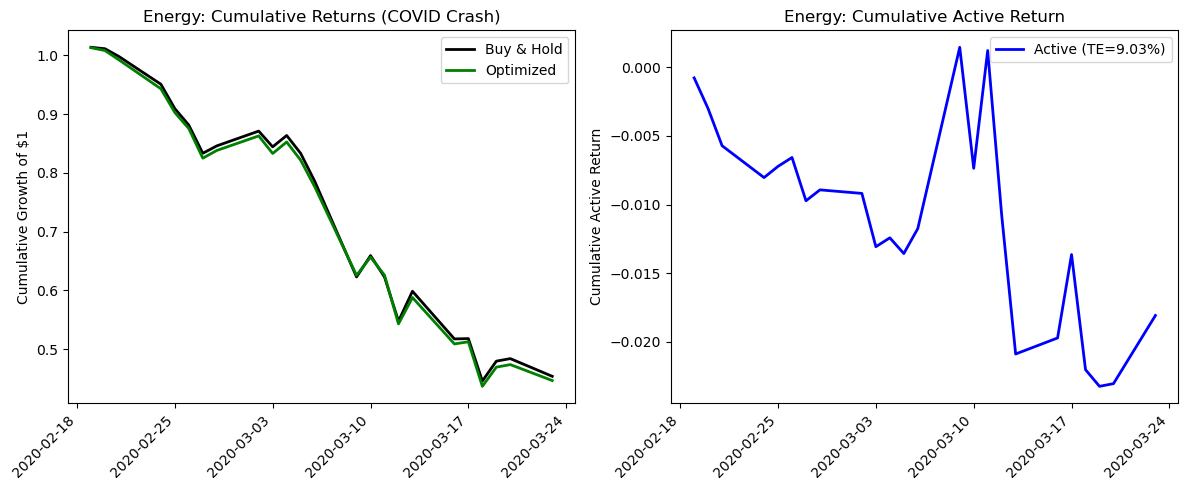

In [40]:
import matplotlib.pyplot as plt

# --- Choose sector ---
sector_name = "Energy"

# Extract daily returns for COVID crash window
r_b = buy_and_hold_sector_daily_returns[sector_name].loc[covid_crash_start:covid_crash_end]
r_d = decarb_sector_daily_returns[sector_name].loc[covid_crash_start:covid_crash_end]

# Compute cumulative returns
cum_b = (1 + r_b).cumprod()
cum_d = (1 + r_d).cumprod()

# Compute cumulative active return (opt – bench)
active = r_d - r_b
cum_active = active.cumsum()

# Tracking Error (annualised) for reference
te_daily = active.std()
te_ann = te_daily * np.sqrt(252)

import matplotlib.dates as mdates

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Left: cumulative returns
axes[0].plot(cum_b.index, cum_b, label="Buy & Hold", lw=2, color="black")
axes[0].plot(cum_d.index, cum_d, label="Optimized", lw=2, color="green")
axes[0].set_title(f"{sector_name}: Cumulative Returns (COVID Crash)")
axes[0].set_ylabel("Cumulative Growth of $1")
axes[0].legend()

# Right: cumulative active returns
axes[1].plot(cum_active.index, cum_active, label=f"Active (TE={te_ann:.2%})", lw=2, color="blue")
axes[1].set_title(f"{sector_name}: Cumulative Active Return")
axes[1].set_ylabel("Cumulative Active Return")
axes[1].legend()

# Apply date formatting to both subplots
for ax in axes:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # weekly ticks
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()



In [32]:
# Define risk-free rate (e.g., 0 for simplicity during crisis)
rf_daily = 0.0

results = []

for sector in buy_and_hold_sector_daily_returns:
    r_b = buy_and_hold_sector_daily_returns[sector].loc[covid_crash_start:covid_crash_end]
    r_d = decarb_sector_daily_returns[sector].loc[covid_crash_start:covid_crash_end]

    # Skip if not enough data
    if len(r_b) < 5 or len(r_d) < 5:
        continue

    # --- Tracking Error ---
    active_returns = r_d - r_b
    te_daily = active_returns.std()
    te_annualised = te_daily * np.sqrt(252)

    # --- Benchmark stats ---
    mean_b = r_b.mean() * 252
    vol_b = r_b.std() * np.sqrt(252)
    sharpe_b = (mean_b - rf_daily * 252) / vol_b if vol_b != 0 else np.nan

    # --- Decarb stats ---
    mean_d = r_d.mean() * 252
    vol_d = r_d.std() * np.sqrt(252)
    sharpe_d = (mean_d - rf_daily * 252) / vol_d if vol_d != 0 else np.nan

    # Store all results
    results.append({
        "Sector": sector,
        "TE_Crash_Annualised": te_annualised,
        "Return_B": mean_b,
        "Vol_B": vol_b,
        "Sharpe_B": sharpe_b,
        "Return_D": mean_d,
        "Vol_D": vol_d,
        "Sharpe_D": sharpe_d
    })

# Create DataFrame
covid_df = pd.DataFrame(results)

# Round appropriately
covid_df["TE_Crash_Annualised"] = covid_df["TE_Crash_Annualised"].round(3)
covid_df[["Return_B", "Return_D", "Vol_B", "Vol_D", "Sharpe_B", "Sharpe_D"]] = \
    covid_df[["Return_B", "Return_D", "Vol_B", "Vol_D", "Sharpe_B", "Sharpe_D"]].round(2)

# Sort if needed
covid_df = covid_df.sort_values(by="TE_Crash_Annualised", ascending=False)

# Display
print(covid_df)


                    Sector  TE_Crash_Annualised  Return_B  Vol_B  Sharpe_B  \
2                Utilities                0.095     -4.32   0.86     -5.04   
8                   Energy                0.090     -7.52   1.12     -6.72   
5                Materials                0.089     -4.38   0.79     -5.54   
1              Health Care                0.087     -3.13   0.70     -4.49   
6              Industrials                0.083     -4.97   0.78     -6.37   
0   Consumer Discretionary                0.076     -4.19   0.78     -5.36   
4              Real Estate                0.071     -4.65   0.89     -5.20   
7               Financials                0.071     -5.07   0.95     -5.35   
3   Information Technology                0.057     -3.17   0.92     -3.45   
10        Consumer Staples                0.057     -2.56   0.71     -3.63   
9   Communication Services                0.034     -3.20   0.71     -4.50   

    Return_D  Vol_D  Sharpe_D  
2      -4.34   0.82     -5.30  

In most sectors, the decarbonised portfolios had slightly worse Sharpe ratios.

Exceptions:

Materials and Communication Services had slightly better Sharpe under decarbonisation — but only marginally

## Realized TE across different TE objectives

Test then realized TE across different TE objectives: 

In [33]:
with open("Data/optimal_portfolios_by_te.pkl", "rb") as f:
    optimal_portfolios_by_te = pickle.load(f)

In [37]:
exclude_list = ['DAY', 'MRNA', 'DOW', 'FOXA', 'CARR', 'OTIS', 'CTVA']

# List of result rows
results = []

for te_cap, sector_data in optimal_portfolios_by_te.items():
    for sector, data in sector_data.items():
        stock_labels = data['stock_labels']
        w_b = data['w_b_vec']
        w_opt = data['w_opt']
        
        # Exclude tickers
        keep_mask = ~stock_labels.isin(exclude_list)
        w_b_new = w_b[keep_mask]
        w_opt_new = w_opt[keep_mask]
        labels_new = stock_labels[keep_mask]

        # Normalize weights
        w_b_new /= w_b_new.sum()
        w_opt_new /= w_opt_new.sum()

        try:
            # Compute returns
            r_b = compute_buy_and_hold_returns(
                monthly_returns_2018_2020,
                weights=w_b_new,
                stock_labels=labels_new
            )

            r_d = compute_fixed_weight_returns(
                monthly_returns_2018_2020,
                weights=w_opt_new,
                stock_labels=labels_new
            )

            # Align indices
            common_index = r_b.index.intersection(r_d.index)
            r_b = r_b.loc[common_index]
            r_d = r_d.loc[common_index]
            active_returns = r_d - r_b

            # TE calculation
            te_monthly = active_returns.std()
            te_annualised = te_monthly * np.sqrt(12)

            # Benchmark stats
            ret_b = r_b.mean() * 12
            vol_b = r_b.std() * np.sqrt(12)
            sharpe_b = ret_b / vol_b if vol_b != 0 else np.nan

            # Optimised stats
            ret_d = r_d.mean() * 12
            vol_d = r_d.std() * np.sqrt(12)
            sharpe_d = ret_d / vol_d if vol_d != 0 else np.nan

            # Store as row
            results.append({
                "Sector": sector,
                "TE_Cap": te_cap,
                "TE_Annualised": te_annualised,
                "Return_B": ret_b,
                "Return_D": ret_d,
                "Vol_B": vol_b,
                "Vol_D": vol_d,
                "Sharpe_B": sharpe_b,
                "Sharpe_D": sharpe_d
            })

        except Exception as e:
            print(f"Failed for {sector} at TE cap {te_cap}: {e}")

df = pd.DataFrame(results)
# Round columns as requested
df["TE_Annualised"] = df["TE_Annualised"].round(3)
df[["Return_B", "Return_D", "Sharpe_B", "Sharpe_D"]] = df[["Return_B", "Return_D", "Sharpe_B", "Sharpe_D"]].round(2)

for te in df['TE_Cap'].unique():
    df_filtered = df.loc[df['TE_Cap'] == te]
    # Sort and display
    df_filtered = df_filtered.sort_values(by=["TE_Annualised"], ascending=[False])
    print(df_filtered.loc[:, ['Sector', 'TE_Cap', 'TE_Annualised', 'Sharpe_B', 'Sharpe_D']])
    print()


                    Sector  TE_Cap  TE_Annualised  Sharpe_B  Sharpe_D
0   Consumer Discretionary    0.01          0.079      1.29      1.25
4              Real Estate    0.01          0.038      0.83      0.77
8                   Energy    0.01          0.034     -0.22     -0.15
5                Materials    0.01          0.033      0.71      0.69
7               Financials    0.01          0.030      0.58      0.52
3   Information Technology    0.01          0.029      1.62      1.47
6              Industrials    0.01          0.026      0.59      0.58
1              Health Care    0.01          0.023      1.00      0.96
2                Utilities    0.01          0.023      1.00      0.92
10        Consumer Staples    0.01          0.017      0.97      0.94
9   Communication Services    0.01          0.010      0.81      0.85

                    Sector  TE_Cap  TE_Annualised  Sharpe_B  Sharpe_D
11  Consumer Discretionary    0.02          0.080      1.29      1.23
15             Real